# 11. Expanded price prediction experiments

Extends notebook 07 with:

1. **Complementary market context** — VIX term structure, rates + yield curve,
   credit spread, dollar, commodities, sector rotation. Each new feature is
   checked against the original SPY features for multicollinearity; features
   with pairwise |r| > 0.80 against any other feature are pruned before modeling.
2. **Regression targets** — raw `forward_ret` (matches 07) plus log-return,
   winsorized (1%/99% clip), and ranks. Heavy-tailed Monday-to-Friday returns
   broke RF/XGB on the raw target in 07 (test R² = -0.015 to -0.08);
   winsorization should restore signal if any exists.
3. **Model family sweep** — Ridge, Lasso, ElasticNet, RF, XGB, LGB,
   HistGradientBoosting. Linear baselines are diagnostic: if Ridge beats trees,
   the relationship is basically linear and trees are over-fitting shuffles.
4. **Group-level ablations** — including the new groups (`vix`, `rates`,
   `credit`, `dollar`, `commodities`, `sectors`). Drop each, measure ΔR².
5. **Lookback ablation** — sweep momentum/volatility windows
   `{5, 10, 20, 40, 60, 120}` to check whether the chosen 20d/60d windows
   are optimal or arbitrary.
6. **Pooled vs per-ticker** — our 07 model is pooled across 35 tickers.
   Do individual-ticker models do meaningfully better?
7. **Directional edge** — even if R² is near zero, does the sign and
   ranking of predictions correlate with realized returns?

**TL;DR expectation**: weekly forward returns from price-only features are
close to a random walk. This notebook quantifies how close, across a much
wider experimental surface than 07. If no configuration lifts out of the
[-0.03, +0.02] R² band, that's the strongest evidence yet that price-only
features are insufficient, and the practical conclusion — use delta —
is already the right one.

In [1]:
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from scipy.stats import rankdata, spearmanr
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

from config import HIGH_QUALITY_TICKERS

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

LABELS_PATH = Path("output/03_weekly_strategy_labels/strategy_labels.parquet")
DAILY_YF_DIR = Path("data/daily_yf")
DAILY_ALPHA_DIR = Path("data/daily_alpha")
OUT_DIR = Path("output/11_expanded_price_prediction_experiments")
OUT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
SPLIT_QUANTILE = 0.8

MARKET_TICKERS = [
    "SPY",
    "QQQ",
    "IWM",
    "VIX",
    "VIX9D",
    "TNX",
    "FVX",
    "IRX",
    "HYG",
    "LQD",
    "TLT",
    "IEF",
    "GLD",
    "USO",
    "UUP",
    "XLK",
    "XLF",
    "XLE",
    "XLV",
    "XLY",
    "XLI",
    "XLU",
    "XLP",
    "XLB",
]
print("configured", len(MARKET_TICKERS), "market context tickers")

configured 24 market context tickers


## Load daily data

HQ tickers from `data/daily_yf/`, market context from the same folder (we fetched
them with `scripts/00_data_fetching/fetch_market_context.py`). SPY already exists
in both `daily_alpha/` and `daily_yf/`; we use the `daily_yf/` copy for consistency
with production (live yfinance quotes).

In [2]:
daily_yf = {}
for t in HIGH_QUALITY_TICKERS:
    p = DAILY_YF_DIR / f"{t}.csv"
    if not p.exists():
        continue
    df = pd.read_csv(p, parse_dates=["date"]).set_index("date").sort_index()
    daily_yf[t] = df

market = {}
for t in MARKET_TICKERS:
    p = DAILY_YF_DIR / f"{t}.csv"
    if not p.exists():
        print(f"  missing: {t}")
        continue
    df = pd.read_csv(p, parse_dates=["date"]).set_index("date").sort_index()
    if df["adjusted_close"].isna().all():
        df["adjusted_close"] = df["close"]
    market[t] = df

print(f"loaded {len(daily_yf)} HQ tickers, {len(market)} market context tickers")
for k in ["SPY", "VIX", "TNX", "HYG", "LQD", "UUP", "GLD", "XLK", "XLP", "XLY"]:
    d = market.get(k)
    if d is not None:
        print(
            f"  {k:<6} {d.index.min().date()} -> {d.index.max().date()}  rows={len(d):>5}"
        )

loaded 35 HQ tickers, 24 market context tickers
  SPY    1993-01-29 -> 2026-04-20  rows= 8362
  VIX    1990-01-02 -> 2026-04-21  rows= 9142
  TNX    1962-01-02 -> 2026-04-20  rows=16089
  HYG    2007-04-11 -> 2026-04-20  rows= 4787
  LQD    2002-07-30 -> 2026-04-20  rows= 5969
  UUP    2007-03-01 -> 2026-04-20  rows= 4815
  GLD    2004-11-18 -> 2026-04-20  rows= 5387
  XLK    1998-12-22 -> 2026-04-20  rows= 6872
  XLP    1998-12-22 -> 2026-04-20  rows= 6872
  XLY    1998-12-22 -> 2026-04-20  rows= 6872


## Extended `compute_features`

All 23 original features (identical to notebook 07) **plus** 15 new complementary
features across 6 new groups. The new groups are chosen to capture regimes that
SPY returns alone miss:

- `vix`: VIX level (current implied vol regime), 5d and 20d VIX change (vol
  expansion/contraction), VIX9D/VIX ratio (term structure, < 1 ≈ contango,
  normal; > 1 ≈ backwardation, stress)
- `rates`: 10-year yield level, 5d/20d change, yield-curve slope
  `(TNX - IRX)` — 10y vs 3m
- `credit`: HYG − LQD 20d return differential (high-yield minus investment-grade;
  negative = credit stress)
- `dollar`: UUP 20d return (dollar index ETF)
- `commodities`: GLD 20d return, USO 20d return
- `sectors`: XLK − SPY and XLY − XLP 20d return differentials (tech vs market,
  cyclical vs defensive rotation)

These are relative / differenced / level features by design — raw sector returns
would just recapitulate SPY. The goal is orthogonal information, not more of the
same.

In [3]:
def compute_rsi(close, period=14):
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)


def compute_features_expanded(ticker_df, market):
    close = ticker_df["adjusted_close"]
    high = ticker_df["high"]
    low = ticker_df["low"]
    volume = ticker_df["volume"]
    log_ret = np.log(close / close.shift(1))

    feat = pd.DataFrame(index=ticker_df.index)

    # momentum (5 features)
    feat["ret_5d"] = close / close.shift(5) - 1
    feat["ret_20d"] = close / close.shift(20) - 1
    feat["ret_60d"] = close / close.shift(60) - 1
    feat["ret_5d_minus_20d"] = feat["ret_5d"] - feat["ret_20d"]
    feat["ret_20d_minus_60d"] = feat["ret_20d"] - feat["ret_60d"]

    # volatility (4)
    feat["vol_20d"] = log_ret.rolling(20).std() * np.sqrt(252)
    feat["vol_60d"] = log_ret.rolling(60).std() * np.sqrt(252)
    feat["vol_ratio_20_60"] = feat["vol_20d"] / feat["vol_60d"]
    hl_sq = np.log(high / low) ** 2 / (4 * np.log(2))
    feat["parkinson_vol_20d"] = np.sqrt(hl_sq.rolling(20).mean() * 252)

    # trend (4)
    ma20 = close.rolling(20).mean()
    ma50 = close.rolling(50).mean()
    ma200 = close.rolling(200).mean()
    feat["close_to_ma20"] = close / ma20 - 1
    feat["close_to_ma50"] = close / ma50 - 1
    feat["close_to_ma200"] = close / ma200 - 1
    feat["ma20_to_ma50"] = ma20 / ma50 - 1

    # drawdown (2)
    feat["max_dd_60d"] = close / close.rolling(60).max() - 1
    feat["dist_from_52w_high"] = close / close.rolling(252).max() - 1

    # mean reversion (3)
    feat["rsi_14"] = compute_rsi(close, 14)
    sd20 = close.rolling(20).std()
    feat["zscore_20d"] = (close - ma20) / sd20
    feat["bbands_pos"] = (close - (ma20 - 2 * sd20)) / (4 * sd20)

    # volume (2)
    feat["volume_ratio_20d"] = volume / volume.rolling(20).mean()
    feat["log_volume"] = np.log(volume.replace(0, 1))

    # spy (3) — original market features
    spy = market["SPY"]["adjusted_close"]
    spy_lr = np.log(spy / spy.shift(1))
    spy_feat = pd.DataFrame(index=spy.index)
    spy_feat["spy_ret_20d"] = spy / spy.shift(20) - 1
    spy_feat["spy_vol_20d"] = spy_lr.rolling(20).std() * np.sqrt(252)
    spy_feat["spy_close_to_ma50"] = spy / spy.rolling(50).mean() - 1

    # vix (4)
    vix = market["VIX"]["adjusted_close"]
    vix9d = market["VIX9D"]["adjusted_close"]
    mkt_feat = pd.DataFrame(index=spy.index)
    mkt_feat["vix_level"] = vix.reindex(spy.index)
    mkt_feat["vix_change_5d"] = vix.reindex(spy.index).pct_change(5)
    mkt_feat["vix_change_20d"] = vix.reindex(spy.index).pct_change(20)
    mkt_feat["vix9d_vix_ratio"] = (vix9d / vix).reindex(spy.index)

    # rates (4)
    tnx = market["TNX"]["adjusted_close"]
    irx = market["IRX"]["adjusted_close"]
    mkt_feat["tnx_level"] = tnx.reindex(spy.index)
    mkt_feat["tnx_change_5d"] = tnx.reindex(spy.index).diff(5)
    mkt_feat["tnx_change_20d"] = tnx.reindex(spy.index).diff(20)
    mkt_feat["yield_curve_slope"] = (tnx - irx).reindex(spy.index)

    # credit (1)
    hyg = market["HYG"]["adjusted_close"]
    lqd = market["LQD"]["adjusted_close"]
    hyg_20 = hyg.pct_change(20).reindex(spy.index)
    lqd_20 = lqd.pct_change(20).reindex(spy.index)
    mkt_feat["credit_spread_proxy"] = hyg_20 - lqd_20

    # dollar (1)
    uup = market["UUP"]["adjusted_close"]
    mkt_feat["uup_ret_20d"] = uup.pct_change(20).reindex(spy.index)

    # commodities (2)
    gld = market["GLD"]["adjusted_close"]
    uso = market["USO"]["adjusted_close"]
    mkt_feat["gld_ret_20d"] = gld.pct_change(20).reindex(spy.index)
    mkt_feat["uso_ret_20d"] = uso.pct_change(20).reindex(spy.index)

    # sectors (2)
    xlk = market["XLK"]["adjusted_close"]
    xlp = market["XLP"]["adjusted_close"]
    xly = market["XLY"]["adjusted_close"]
    spy_20 = spy.pct_change(20)
    mkt_feat["xlk_minus_spy_20d"] = (xlk.pct_change(20) - spy_20).reindex(spy.index)
    mkt_feat["xly_minus_xlp_20d"] = (xly.pct_change(20) - xlp.pct_change(20)).reindex(
        spy.index
    )

    return feat.join(spy_feat, how="left").join(mkt_feat, how="left")


FEATURE_GROUPS = {
    "momentum": [
        "ret_5d",
        "ret_20d",
        "ret_60d",
        "ret_5d_minus_20d",
        "ret_20d_minus_60d",
    ],
    "volatility": ["vol_20d", "vol_60d", "vol_ratio_20_60", "parkinson_vol_20d"],
    "trend": ["close_to_ma20", "close_to_ma50", "close_to_ma200", "ma20_to_ma50"],
    "drawdown": ["max_dd_60d", "dist_from_52w_high"],
    "mean_reversion": ["rsi_14", "zscore_20d", "bbands_pos"],
    "volume": ["volume_ratio_20d", "log_volume"],
    "spy": ["spy_ret_20d", "spy_vol_20d", "spy_close_to_ma50"],
    "vix": ["vix_level", "vix_change_5d", "vix_change_20d", "vix9d_vix_ratio"],
    "rates": ["tnx_level", "tnx_change_5d", "tnx_change_20d", "yield_curve_slope"],
    "credit": ["credit_spread_proxy"],
    "dollar": ["uup_ret_20d"],
    "commodities": ["gld_ret_20d", "uso_ret_20d"],
    "sectors": ["xlk_minus_spy_20d", "xly_minus_xlp_20d"],
}
ALL_FEATURES = [f for g in FEATURE_GROUPS.values() for f in g]
NEW_FEATURES = [
    f
    for g in ["vix", "rates", "credit", "dollar", "commodities", "sectors"]
    for f in FEATURE_GROUPS[g]
]
print(f"{len(ALL_FEATURES)} features total ({len(NEW_FEATURES)} new)")

37 features total (14 new)


## Build feature table

Pool across HQ tickers. Same (ticker, monday) grain as notebook 07. Drop rows with
any NaN in `ALL_FEATURES` (rolling windows up to 252d mean younger tickers get
truncated at the head).

In [4]:
features_by_ticker = {
    t: compute_features_expanded(daily_yf[t], market) for t in daily_yf
}
print(f"computed features for {len(features_by_ticker)} tickers")

labels = pd.read_parquet(LABELS_PATH)
keys = labels[
    ["ticker", "monday_date", "monday_close", "friday_date", "friday_close"]
].drop_duplicates()
keys["monday_date"] = pd.to_datetime(keys["monday_date"])
keys["friday_date"] = pd.to_datetime(keys["friday_date"])

rows = []
for r in keys.itertuples():
    tf = features_by_ticker.get(r.ticker)
    if tf is None:
        continue
    try:
        fvals = (
            tf.loc[r.monday_date]
            if r.monday_date in tf.index
            else tf.loc[: r.monday_date].iloc[-1]
        )
    except KeyError, IndexError:
        continue
    rec = {
        "ticker": r.ticker,
        "monday_date": r.monday_date,
        "friday_date": r.friday_date,
        "monday_close": r.monday_close,
        "friday_close": r.friday_close,
    }
    for f in ALL_FEATURES:
        rec[f] = fvals.get(f, np.nan)
    rows.append(rec)

features = pd.DataFrame(rows)
features["forward_ret"] = features["friday_close"] / features["monday_close"] - 1
features["log_forward_ret"] = np.log(
    features["friday_close"] / features["monday_close"]
)

pre = len(features)
features = features.dropna(subset=ALL_FEATURES).reset_index(drop=True)
print(
    f"{pre:,} rows -> {len(features):,} after dropping NaN (lost {pre - len(features):,})"
)

computed features for 35 tickers


6,902 rows -> 6,711 after dropping NaN (lost 191)


## Multicollinearity screen

Target: no pair of features with |r| > 0.80 (industry rule-of-thumb) so each
feature can contribute unique information to linear models. Tree models are
robust to multicollinearity, but keeping the feature set honest matters for
the ablation (if feature A is a linear combination of B and C, dropping A
barely moves R² and we draw wrong conclusions).

top-10 most-collinear features (max |r| vs any other):
bbands_pos           1.00
zscore_20d           1.00
ret_60d              0.96
ret_20d_minus_60d    0.96
vol_20d              0.95
parkinson_vol_20d    0.95
ret_20d              0.94
ret_5d_minus_20d     0.94
close_to_ma50        0.88
vol_60d              0.87


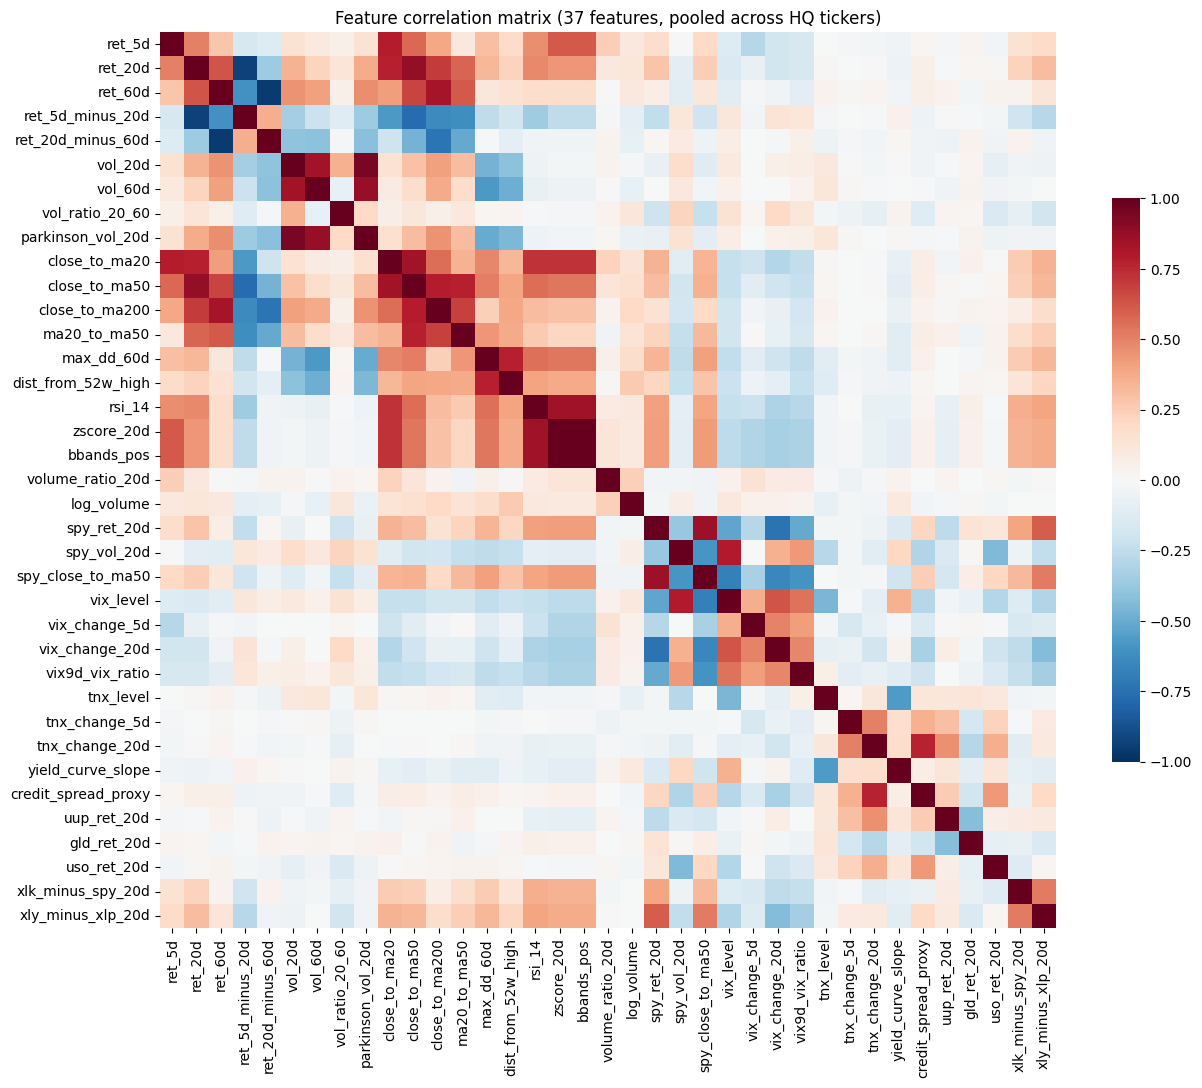

In [5]:
corr = features[ALL_FEATURES].corr().abs()
corr_vals = corr.to_numpy(copy=True)
np.fill_diagonal(corr_vals, 0)
corr = pd.DataFrame(corr_vals, index=corr.index, columns=corr.columns)

max_corr = corr.max().sort_values(ascending=False)
print("top-10 most-collinear features (max |r| vs any other):")
print(max_corr.head(10).round(2).to_string())

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    features[ALL_FEATURES].corr(),
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.6},
    ax=ax,
    xticklabels=True,
    yticklabels=True,
)
ax.set_title(
    f"Feature correlation matrix ({len(ALL_FEATURES)} features, pooled across HQ tickers)"
)
fig.tight_layout()
fig.savefig(OUT_DIR / "correlation_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()
plt.close(fig)

In [6]:
# Greedy pruning: walk features ordered by group priority; drop any that correlates
# > 0.80 with an already-kept feature. Priority: keep original (07) features first,
# then add new ones only if they pass the orthogonality test.
threshold = 0.80
priority = (
    FEATURE_GROUPS["momentum"]
    + FEATURE_GROUPS["volatility"]
    + FEATURE_GROUPS["trend"]
    + FEATURE_GROUPS["drawdown"]
    + FEATURE_GROUPS["mean_reversion"]
    + FEATURE_GROUPS["volume"]
    + FEATURE_GROUPS["spy"]
    + FEATURE_GROUPS["vix"]
    + FEATURE_GROUPS["rates"]
    + FEATURE_GROUPS["credit"]
    + FEATURE_GROUPS["dollar"]
    + FEATURE_GROUPS["commodities"]
    + FEATURE_GROUPS["sectors"]
)
kept: list[str] = []
dropped_for_collinearity: list[tuple[str, str, float]] = []
corr_raw = features[ALL_FEATURES].corr().abs()
for f in priority:
    bad = False
    for k in kept:
        if corr_raw.loc[f, k] > threshold:
            dropped_for_collinearity.append((f, k, float(corr_raw.loc[f, k])))
            bad = True
            break
    if not bad:
        kept.append(f)
print(
    f"kept {len(kept)} / {len(ALL_FEATURES)} features after |r| <= {threshold} pruning"
)
print("dropped (feature -> because of -> correlation):")
for d in dropped_for_collinearity:
    print(f"  {d[0]:<22} -> {d[1]:<22} r={d[2]:.2f}")
print()
print("kept set:")
print(", ".join(kept))

kept 28 / 37 features after |r| <= 0.8 pruning
dropped (feature -> because of -> correlation):
  ret_5d_minus_20d       -> ret_20d                r=0.94
  ret_20d_minus_60d      -> ret_60d                r=0.96
  vol_60d                -> vol_20d                r=0.84
  parkinson_vol_20d      -> vol_20d                r=0.95
  close_to_ma50          -> ret_20d                r=0.88
  close_to_ma200         -> ret_60d                r=0.84
  zscore_20d             -> rsi_14                 r=0.85
  bbands_pos             -> rsi_14                 r=0.85
  spy_close_to_ma50      -> spy_ret_20d            r=0.86

kept set:
ret_5d, ret_20d, ret_60d, vol_20d, vol_ratio_20_60, close_to_ma20, ma20_to_ma50, max_dd_60d, dist_from_52w_high, rsi_14, volume_ratio_20d, log_volume, spy_ret_20d, spy_vol_20d, vix_level, vix_change_5d, vix_change_20d, vix9d_vix_ratio, tnx_level, tnx_change_5d, tnx_change_20d, yield_curve_slope, credit_spread_proxy, uup_ret_20d, gld_ret_20d, uso_ret_20d, xlk_minus_spy_2

## Regression experiments: target transformations

We sweep four target definitions against three baseline models (Ridge, RF, XGB):

- `forward_ret` — raw, matches notebook 07
- `log_forward_ret` — log return (tames right-skew slightly)
- `winsor_forward_ret` — `forward_ret` winsorized at 1%/99% quantiles (computed on
  *training set only* to avoid lookahead)
- `rank_forward_ret` — quantile-transformed to uniform[0, 1] on training set

For each (model, target) we report test R² (on the native scale — we back-transform
predictions when needed), MSE, Spearman rank correlation, and hit-rate
(`sign(pred) == sign(realized)`).

In [7]:
features = features.sort_values("monday_date").reset_index(drop=True)
split_date = features["monday_date"].quantile(SPLIT_QUANTILE)
train_mask = features["monday_date"] < split_date
test_mask = ~train_mask
print(
    f"split at {split_date.date()}: train={train_mask.sum():,}, test={test_mask.sum():,}"
)

FULL_FEATURES = ALL_FEATURES
PRUNED_FEATURES = kept

X_train_full = features.loc[train_mask, FULL_FEATURES].values
X_test_full = features.loc[test_mask, FULL_FEATURES].values
X_train_pruned = features.loc[train_mask, PRUNED_FEATURES].values
X_test_pruned = features.loc[test_mask, PRUNED_FEATURES].values

y_train_raw = features.loc[train_mask, "forward_ret"].values
y_test_raw = features.loc[test_mask, "forward_ret"].values
y_train_log = features.loc[train_mask, "log_forward_ret"].values
y_test_log = features.loc[test_mask, "log_forward_ret"].values

# winsorize at train-set quantiles
lo, hi = np.quantile(y_train_raw, [0.01, 0.99])
y_train_win = np.clip(y_train_raw, lo, hi)
y_test_win = np.clip(y_test_raw, lo, hi)
print(f"winsor bounds from train: [{lo:.4f}, {hi:.4f}]")

# rank transform from train
n_train = len(y_train_raw)
train_ranks = rankdata(y_train_raw) / n_train  # 0..1
# map test points into the train rank space by interpolation
sorted_train = np.sort(y_train_raw)
y_test_rank = np.searchsorted(sorted_train, y_test_raw) / n_train
y_train_rank = train_ranks

targets = {
    "forward_ret": (y_train_raw, y_test_raw),
    "log_forward_ret": (y_train_log, y_test_log),
    "winsor_forward_ret": (y_train_win, y_test_win),
    "rank_forward_ret": (y_train_rank, y_test_rank),
}
for k, (yt, ye) in targets.items():
    print(
        f"  {k:<20} train_mean={yt.mean():+.4f} train_std={yt.std():.4f}  "
        f"test_mean={ye.mean():+.4f} test_std={ye.std():.4f}"
    )

split at 2025-05-19: train=5,338, test=1,373
winsor bounds from train: [-0.2006, 0.3295]
  forward_ret          train_mean=+0.0074 train_std=0.1085  test_mean=-0.0026 test_std=0.0901
  log_forward_ret      train_mean=+0.0021 train_std=0.1076  test_mean=-0.0065 test_std=0.0867
  winsor_forward_ret   train_mean=+0.0063 train_std=0.0805  test_mean=-0.0031 test_std=0.0848
  rank_forward_ret     train_mean=+0.5001 train_std=0.2887  test_mean=+0.4531 test_std=0.2949


In [8]:
def eval_on_raw(y_true_raw, y_pred_any, model_target):
    """Evaluate any (target, prediction) against the raw forward_ret scale.

    For target=='rank_forward_ret' we evaluate rank-based metrics only
    (R²/MSE on raw scale don't make sense). Spearman and hit-rate always
    evaluate against raw returns."""
    out = {}
    if model_target == "forward_ret":
        out["test_r2"] = r2_score(y_true_raw, y_pred_any)
        out["test_mse"] = float(np.mean((y_true_raw - y_pred_any) ** 2))
    elif model_target == "log_forward_ret":
        # back-transform: exp(log_ret) - 1
        y_pred_raw = np.exp(y_pred_any) - 1
        out["test_r2"] = r2_score(y_true_raw, y_pred_raw)
        out["test_mse"] = float(np.mean((y_true_raw - y_pred_raw) ** 2))
    elif model_target == "winsor_forward_ret":
        out["test_r2"] = r2_score(y_true_raw, y_pred_any)
        out["test_mse"] = float(np.mean((y_true_raw - y_pred_any) ** 2))
    elif model_target == "rank_forward_ret":
        out["test_r2"] = np.nan
        out["test_mse"] = np.nan
    rho, _ = spearmanr(y_pred_any, y_true_raw)
    out["spearman"] = float(rho)
    # hit rate on sign (skip if pred is a rank 0..1)
    if model_target == "rank_forward_ret":
        out["hit_rate"] = float(((y_pred_any > 0.5) == (y_true_raw > 0)).mean())
    else:
        out["hit_rate"] = float((np.sign(y_pred_any) == np.sign(y_true_raw)).mean())
    return out


def fit_eval(model, Xtr, ytr, Xte, yte_target, yte_raw, target_name):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    return eval_on_raw(yte_raw, pred, target_name)

In [9]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train_pruned)
X_test_std = scaler.transform(X_test_pruned)


def make_models():
    return {
        "Ridge": Ridge(alpha=10.0, random_state=SEED),
        "Lasso": Lasso(alpha=0.001, random_state=SEED, max_iter=10000),
        "ElasticNet": ElasticNet(
            alpha=0.001, l1_ratio=0.5, random_state=SEED, max_iter=10000
        ),
        "RF": RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=20,
            n_jobs=-1,
            random_state=SEED,
        ),
        "XGB": xgb.XGBRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            random_state=SEED,
            n_jobs=-1,
            verbosity=0,
        ),
        "LGB": lgb.LGBMRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        ),
        "HGB": HistGradientBoostingRegressor(
            max_iter=300,
            max_depth=5,
            learning_rate=0.05,
            random_state=SEED,
        ),
    }


results = []
for tgt_name, (y_tr, y_te) in targets.items():
    for m_name, m in make_models().items():
        # linear models get scaled data; trees get raw
        is_linear = m_name in {"Ridge", "Lasso", "ElasticNet"}
        Xtr = X_train_std if is_linear else X_train_pruned
        Xte = X_test_std if is_linear else X_test_pruned
        metrics = fit_eval(m, Xtr, y_tr, Xte, y_te, y_test_raw, tgt_name)
        results.append({"target": tgt_name, "model": m_name, **metrics})

res_df = pd.DataFrame(results)
res_df_display = res_df.copy()
res_df_display["test_r2"] = res_df_display["test_r2"].round(4)
res_df_display["test_mse"] = res_df_display["test_mse"].round(6)
res_df_display["spearman"] = res_df_display["spearman"].round(4)
res_df_display["hit_rate"] = res_df_display["hit_rate"].round(4)
print(res_df_display.to_string(index=False))

            target      model  test_r2  test_mse  spearman  hit_rate
       forward_ret      Ridge  -0.0946  0.008878   -0.0360    0.4800
       forward_ret      Lasso  -0.0299  0.008353   -0.0262    0.4683
       forward_ret ElasticNet  -0.0556  0.008562   -0.0481    0.4683
       forward_ret         RF  -0.0045  0.008147    0.0400    0.5004
       forward_ret        XGB  -0.1483  0.009314   -0.0349    0.5171
       forward_ret        LGB  -0.0063  0.008162    0.0620    0.5273
       forward_ret        HGB  -0.0063  0.008162    0.0696    0.5237
   log_forward_ret      Ridge  -0.0653  0.008640   -0.0283    0.4938
   log_forward_ret      Lasso  -0.0182  0.008258    0.0020    0.4851
   log_forward_ret ElasticNet  -0.0386  0.008423   -0.0391    0.4975
   log_forward_ret         RF   0.0079  0.008046    0.1154    0.5266
   log_forward_ret        XGB  -0.0806  0.008764    0.0892    0.5382
   log_forward_ret        LGB  -0.0451  0.008476    0.0309    0.5215
   log_forward_ret        HGB  -0.

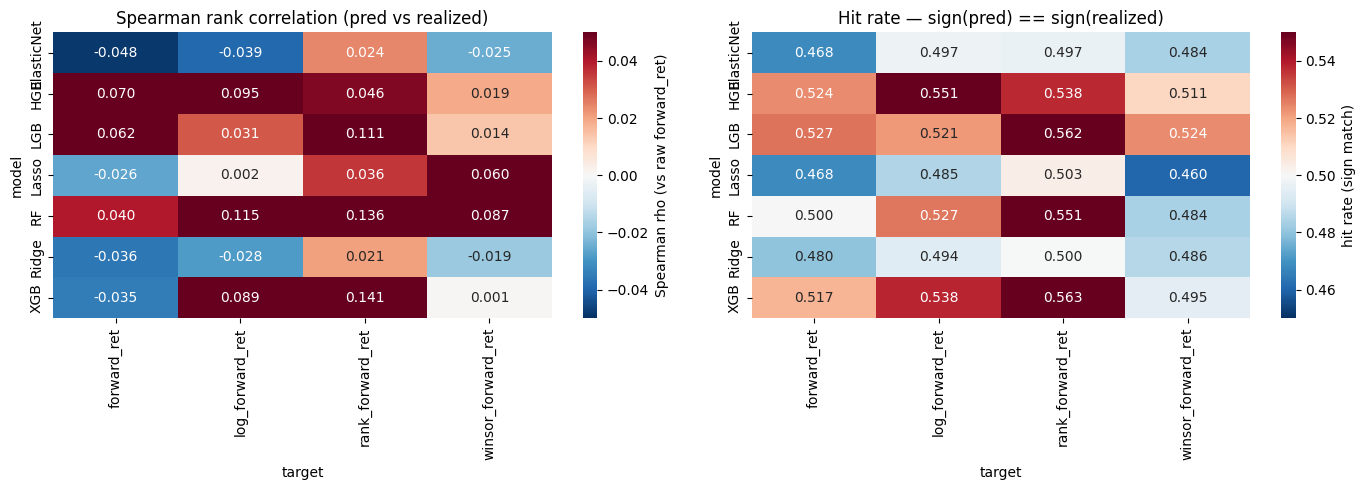

In [10]:
# Plot — Spearman rank correlation per (target × model). Rank corr is the
# cleanest headline metric — positive values mean the model ordering beats random.
pivot_spearman = res_df.pivot(index="model", columns="target", values="spearman")
pivot_hit = res_df.pivot(index="model", columns="target", values="hit_rate")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    pivot_spearman,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-0.05,
    vmax=0.05,
    ax=axes[0],
    cbar_kws={"label": "Spearman rho (vs raw forward_ret)"},
)
axes[0].set_title("Spearman rank correlation (pred vs realized)")
sns.heatmap(
    pivot_hit,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0.5,
    vmin=0.45,
    vmax=0.55,
    ax=axes[1],
    cbar_kws={"label": "hit rate (sign match)"},
)
axes[1].set_title("Hit rate — sign(pred) == sign(realized)")
fig.tight_layout()
fig.savefig(OUT_DIR / "target_model_sweep.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Group-level ablation (expanded)

Pick the best (target, model) from the sweep above. Drop each feature group;
measure change in Spearman rank correlation (a cleaner signal than R² when the
baseline R² is near zero).

In [11]:
# Select best config by test Spearman (ignoring rank-target which can't be fairly compared on R²)
non_rank = res_df[res_df["target"] != "rank_forward_ret"].copy()
best_row = non_rank.sort_values("spearman", ascending=False).iloc[0]
best_target = best_row["target"]
best_model_name = best_row["model"]
print(
    f"best config: target={best_target}  model={best_model_name}  "
    f"spearman={best_row['spearman']:.4f}  r2={best_row['test_r2']:.4f}"
)

y_tr, y_te = targets[best_target]
is_linear = best_model_name in {"Ridge", "Lasso", "ElasticNet"}


def eval_with_features(feat_list: list[str]) -> dict:
    Xtr = features.loc[train_mask, feat_list].values
    Xte = features.loc[test_mask, feat_list].values
    if is_linear:
        sc = StandardScaler()
        Xtr = sc.fit_transform(Xtr)
        Xte = sc.transform(Xte)
    m = make_models()[best_model_name]
    m.fit(Xtr, y_tr)
    pred = m.predict(Xte)
    return eval_on_raw(y_test_raw, pred, best_target)


baseline_feats = PRUNED_FEATURES
base_metrics = eval_with_features(baseline_feats)
ablation_rows = [
    {
        "ablation": "ALL (pruned baseline)",
        "n_features": len(baseline_feats),
        "spearman": base_metrics["spearman"],
        "test_r2": base_metrics["test_r2"],
        "hit_rate": base_metrics["hit_rate"],
    }
]
for gname, gfeats in FEATURE_GROUPS.items():
    kept_after_drop = [f for f in baseline_feats if f not in gfeats]
    if len(kept_after_drop) == len(baseline_feats):
        # group had no surviving features after multicollinearity prune — skip
        continue
    m = eval_with_features(kept_after_drop)
    ablation_rows.append(
        {
            "ablation": f"drop {gname}",
            "n_features": len(kept_after_drop),
            "spearman": m["spearman"],
            "test_r2": m["test_r2"],
            "hit_rate": m["hit_rate"],
        }
    )

ab_df = pd.DataFrame(ablation_rows)
ab_df["delta_spearman"] = ab_df["spearman"] - base_metrics["spearman"]
ab_df["delta_r2"] = ab_df["test_r2"] - base_metrics["test_r2"]
print(ab_df.round(4).to_string(index=False))

best config: target=log_forward_ret  model=RF  spearman=0.1154  r2=0.0079


             ablation  n_features  spearman  test_r2  hit_rate  delta_spearman  delta_r2
ALL (pruned baseline)          28    0.1154   0.0079    0.5266          0.0000    0.0000
        drop momentum          25    0.1031   0.0046    0.5462         -0.0123   -0.0033
      drop volatility          26    0.0897   0.0041    0.5164         -0.0257   -0.0038
           drop trend          26    0.1495   0.0195    0.5390          0.0341    0.0116
        drop drawdown          26    0.1135   0.0071    0.5368         -0.0019   -0.0008
  drop mean_reversion          27    0.1145   0.0078    0.5302         -0.0009   -0.0001
          drop volume          26    0.1214   0.0082    0.5382          0.0060    0.0003
             drop spy          26    0.0787   0.0027    0.5055         -0.0367   -0.0052
             drop vix          24    0.0845   0.0046    0.5368         -0.0308   -0.0033
           drop rates          24    0.0930   0.0054    0.5324         -0.0224   -0.0026
          drop credit

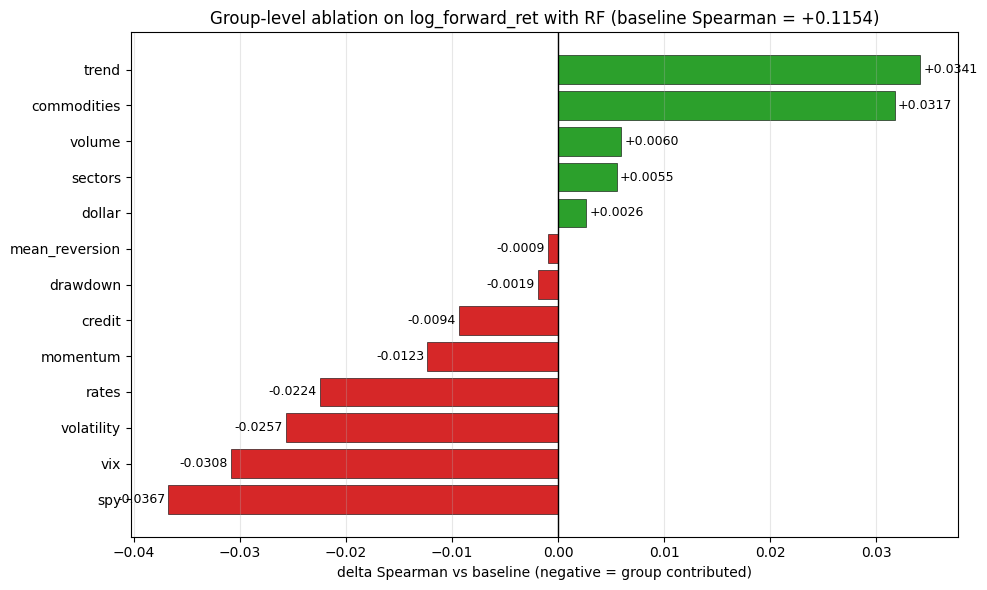

In [12]:
ab_plot = ab_df.iloc[1:].copy().sort_values("delta_spearman")
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["tab:red" if d < 0 else "tab:green" for d in ab_plot["delta_spearman"]]
ax.barh(
    [r.replace("drop ", "") for r in ab_plot["ablation"]],
    ab_plot["delta_spearman"],
    color=colors,
    edgecolor="black",
    linewidth=0.4,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("delta Spearman vs baseline (negative = group contributed)")
ax.set_title(
    f"Group-level ablation on {best_target} with {best_model_name} "
    f"(baseline Spearman = {base_metrics['spearman']:+.4f})"
)
ax.grid(alpha=0.3, axis="x")
for i, row in enumerate(ab_plot.itertuples()):
    ax.text(
        row.delta_spearman + (0.0003 if row.delta_spearman >= 0 else -0.0003),
        i,
        f"{row.delta_spearman:+.4f}",
        va="center",
        ha="left" if row.delta_spearman >= 0 else "right",
        fontsize=9,
    )
fig.tight_layout()
fig.savefig(OUT_DIR / "group_ablation.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Lookback-window ablation

Do different momentum/volatility windows produce meaningfully different R²?
Train a model with a **single** `ret_Xd` or `vol_Xd` feature at a time; see
whether a particular window dominates.

This is diagnostic: if all windows look equally (un)predictive, we're truly
in random-walk territory. If a narrow window stands out, we may have been
under-exploiting it.

In [13]:
windows = [5, 10, 20, 40, 60, 120]


# Precompute ret_Xd and vol_Xd series per ticker, then asof-merge on monday_date.
def precompute_lookback_series(close: pd.Series, window: int, kind: str) -> pd.Series:
    if kind == "ret":
        return close / close.shift(window) - 1
    else:
        log_ret = np.log(close / close.shift(1))
        return log_ret.rolling(window).std() * np.sqrt(252)


lookback_rows = []
for w in windows:
    for kind in ["ret", "vol"]:
        per_ticker_series = {
            t: precompute_lookback_series(daily_yf[t]["adjusted_close"], w, kind)
            for t in daily_yf
        }
        vals = []
        for r in features.itertuples():
            s = per_ticker_series.get(r.ticker)
            if s is None:
                vals.append(np.nan)
                continue
            if r.monday_date in s.index:
                vals.append(s.loc[r.monday_date])
            else:
                # pad to prior business day
                prior = s.loc[: r.monday_date]
                vals.append(prior.iloc[-1] if len(prior) else np.nan)
        arr = np.asarray(vals, dtype=float)
        train_arr = arr[train_mask.values]
        test_arr = arr[test_mask.values]
        tmask = ~np.isnan(train_arr)
        emask = ~np.isnan(test_arr)
        if tmask.sum() < 100 or emask.sum() < 50:
            continue
        Xtr = train_arr[tmask].reshape(-1, 1)
        Xte = test_arr[emask].reshape(-1, 1)
        ytr = y_train_win[tmask]
        yte = y_test_raw[emask]
        m = RandomForestRegressor(
            n_estimators=200,
            max_depth=5,
            min_samples_leaf=50,
            n_jobs=-1,
            random_state=SEED,
        )
        m.fit(Xtr, ytr)
        pred = m.predict(Xte)
        metrics = eval_on_raw(yte, pred, "winsor_forward_ret")
        lookback_rows.append(
            {
                "feature": f"{kind}_{w}d",
                "kind": kind,
                "window": w,
                "n_train": int(tmask.sum()),
                "n_test": int(emask.sum()),
                **metrics,
            }
        )

lb_df = pd.DataFrame(lookback_rows)
print(lb_df.round(4).to_string(index=False))

 feature kind  window  n_train  n_test  test_r2  test_mse  spearman  hit_rate
  ret_5d  ret       5     5338    1373  -0.0164    0.0082   -0.0453    0.4516
  vol_5d  vol       5     5338    1373  -0.0171    0.0082   -0.0190    0.4625
 ret_10d  ret      10     5338    1373  -0.0187    0.0083    0.0188    0.4647
 vol_10d  vol      10     5338    1373  -0.0108    0.0082   -0.0148    0.4647
 ret_20d  ret      20     5338    1373  -0.0054    0.0082    0.0172    0.4596
 vol_20d  vol      20     5338    1373  -0.0188    0.0083   -0.0341    0.4618
 ret_40d  ret      40     5338    1373  -0.0318    0.0084   -0.0276    0.4523
 vol_40d  vol      40     5338    1373  -0.0262    0.0083   -0.0459    0.4698
 ret_60d  ret      60     5338    1373  -0.0341    0.0084   -0.0873    0.4574
 vol_60d  vol      60     5338    1373  -0.0091    0.0082   -0.0059    0.4632
ret_120d  ret     120     5338    1373  -0.0142    0.0082    0.0029    0.4545
vol_120d  vol     120     5338    1373  -0.0125    0.0082    0.0

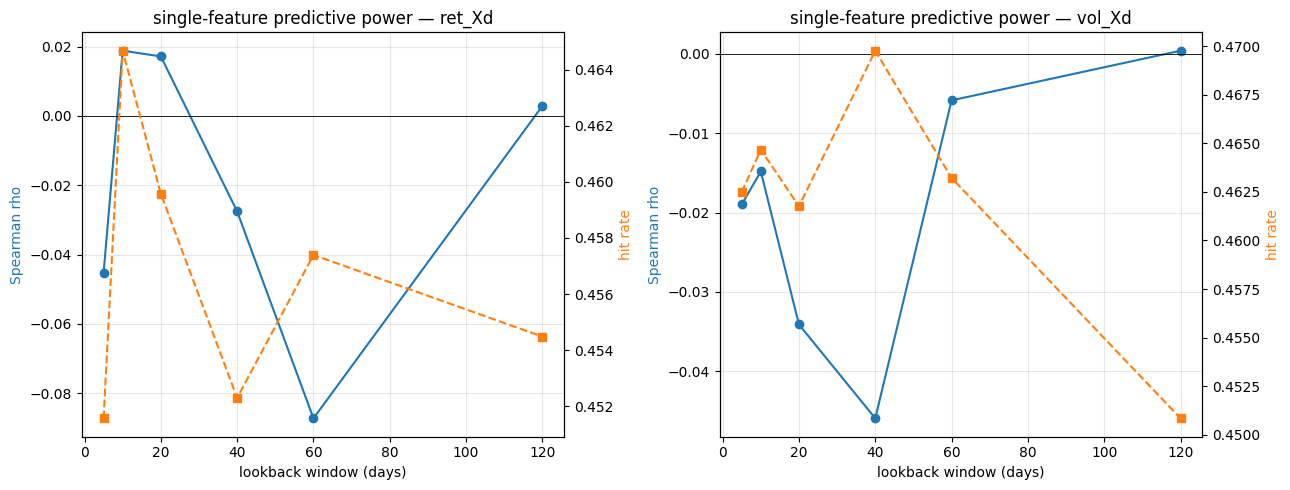

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, kind in zip(axes, ["ret", "vol"]):
    sub = lb_df[lb_df["kind"] == kind]
    ax.plot(sub["window"], sub["spearman"], "o-", label="Spearman", color="tab:blue")
    ax2 = ax.twinx()
    ax2.plot(
        sub["window"], sub["hit_rate"], "s--", label="hit rate", color="tab:orange"
    )
    ax.set_xlabel("lookback window (days)")
    ax.set_ylabel("Spearman rho", color="tab:blue")
    ax2.set_ylabel("hit rate", color="tab:orange")
    ax.set_title(f"single-feature predictive power — {kind}_Xd")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "lookback_sweep.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Pooled vs per-ticker

Maybe pooling averages out ticker-idiosyncratic signals. Train a dedicated model
per HQ ticker on its own history and compare.

In [15]:
per_ticker_rows = []
for t in HIGH_QUALITY_TICKERS:
    sub = features[features["ticker"] == t].sort_values("monday_date")
    if len(sub) < 100:
        continue
    split_t = sub["monday_date"].quantile(SPLIT_QUANTILE)
    tr = sub[sub["monday_date"] < split_t]
    te = sub[sub["monday_date"] >= split_t]
    if len(tr) < 50 or len(te) < 20:
        continue
    Xtr = tr[PRUNED_FEATURES].values
    Xte = te[PRUNED_FEATURES].values
    ytr_raw = tr["forward_ret"].values
    yte_raw = te["forward_ret"].values
    lo_t, hi_t = np.quantile(ytr_raw, [0.01, 0.99])
    ytr_win = np.clip(ytr_raw, lo_t, hi_t)
    m = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=SEED,
    )
    m.fit(Xtr, ytr_win)
    pred = m.predict(Xte)
    metrics = eval_on_raw(yte_raw, pred, "winsor_forward_ret")
    per_ticker_rows.append(
        {
            "ticker": t,
            "n_train": len(tr),
            "n_test": len(te),
            **metrics,
        }
    )

pt_df = pd.DataFrame(per_ticker_rows).sort_values("spearman", ascending=False)
print(f"per-ticker models: {len(pt_df)} tickers")
print(pt_df.round(4).head(10).to_string(index=False))
print("...")
print(pt_df.round(4).tail(5).to_string(index=False))
print()
print(
    f"per-ticker Spearman  median={pt_df['spearman'].median():+.4f}  "
    f"mean={pt_df['spearman'].mean():+.4f}  "
    f">0 rate={(pt_df['spearman'] > 0).mean():.2%}"
)

# Compare to pooled baseline
print(f"pooled baseline Spearman (best config):  {base_metrics['spearman']:+.4f}")

per-ticker models: 27 tickers
ticker  n_train  n_test  test_r2  test_mse  spearman  hit_rate
  SMCI      124      32  -0.1922    0.0121    0.3816    0.5000
  NVDA      223      56   0.0621    0.0031    0.2436    0.4643
   GME      220      55  -0.0194    0.0039    0.2266    0.6364
  AMZN      223      56  -0.0702    0.0021    0.1899    0.5000
   AMD      224      56   0.0362    0.0042    0.1893    0.5357
  DELL      140      36   0.0060    0.0033    0.1743    0.5833
  IONQ      112      28  -0.0100    0.0169    0.1533    0.5000
  TSLA      223      56  -0.0138    0.0046    0.1528    0.5179
  MSFT      223      56  -0.0173    0.0013    0.1295    0.4821
  META      138      35  -0.1384    0.0021    0.1261    0.5143
...
ticker  n_train  n_test  test_r2  test_mse  spearman  hit_rate
  AAPL      216      55  -0.0837    0.0018   -0.0271    0.5636
   TSM      224      56  -0.0538    0.0024   -0.0344    0.5893
  RKLB      101      26  -0.0740    0.0137   -0.0995    0.4231
  APLD      101      

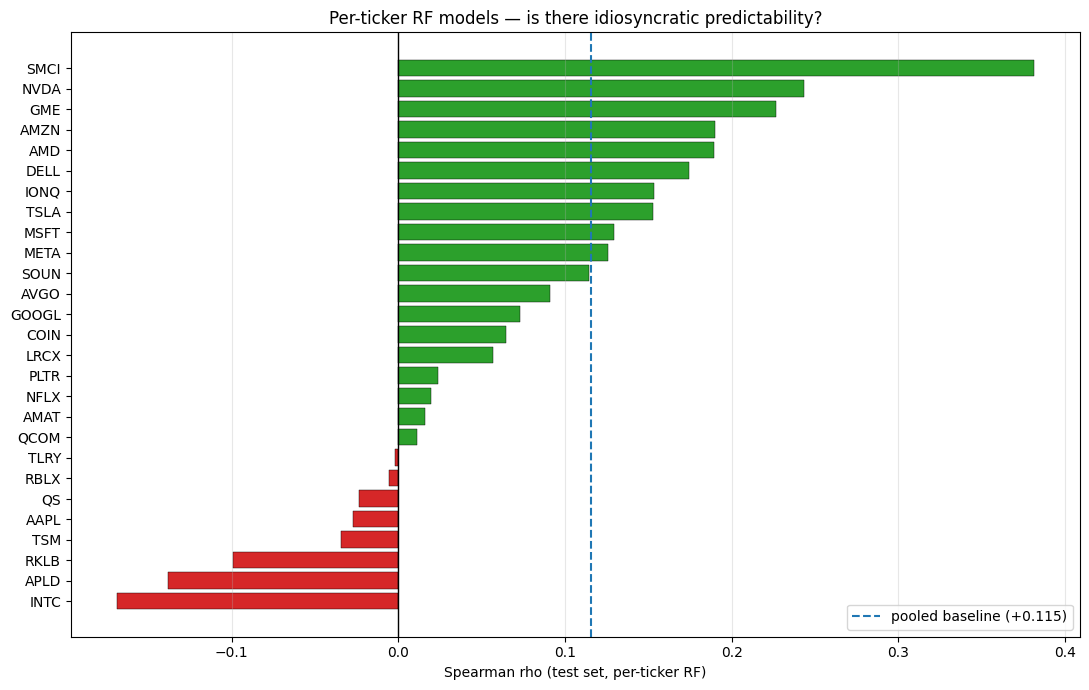

In [16]:
fig, ax = plt.subplots(figsize=(11, 7))
pt_sorted = pt_df.sort_values("spearman")
colors = ["tab:red" if s < 0 else "tab:green" for s in pt_sorted["spearman"]]
ax.barh(
    pt_sorted["ticker"],
    pt_sorted["spearman"],
    color=colors,
    edgecolor="black",
    linewidth=0.3,
)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(
    base_metrics["spearman"],
    color="tab:blue",
    linestyle="--",
    linewidth=1.5,
    label=f"pooled baseline ({base_metrics['spearman']:+.3f})",
)
ax.set_xlabel("Spearman rho (test set, per-ticker RF)")
ax.set_title("Per-ticker RF models — is there idiosyncratic predictability?")
ax.legend(loc="lower right")
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig(OUT_DIR / "per_ticker_spearman.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Directional-edge check: top vs bottom quintile

Even if R² is near zero, rankings can still be useful. For each week, sort test
predictions into quintiles; does the top quintile realize higher returns than
the bottom quintile? This is the cleanest test of "does this model produce a
tradeable ordering".

In [17]:
# Use the best (target, model) from earlier for the quintile test
y_tr, y_te = targets[best_target]
is_linear = best_model_name in {"Ridge", "Lasso", "ElasticNet"}
if is_linear:
    sc = StandardScaler()
    Xtr = sc.fit_transform(features.loc[train_mask, PRUNED_FEATURES].values)
    Xte = sc.transform(features.loc[test_mask, PRUNED_FEATURES].values)
else:
    Xtr = features.loc[train_mask, PRUNED_FEATURES].values
    Xte = features.loc[test_mask, PRUNED_FEATURES].values
m = make_models()[best_model_name]
m.fit(Xtr, y_tr)
test_preds = m.predict(Xte)

test_df = features.loc[test_mask, ["ticker", "monday_date", "forward_ret"]].copy()
test_df["pred"] = test_preds
test_df["quintile"] = pd.qcut(
    test_df["pred"], 5, labels=["Q1 (low)", "Q2", "Q3", "Q4", "Q5 (high)"]
)

quintile_stats = test_df.groupby("quintile", observed=True)["forward_ret"].agg(
    ["mean", "median", "std", "count"]
)
quintile_stats["sharpe_weekly"] = quintile_stats["mean"] / quintile_stats[
    "std"
].replace(0, np.nan)
print(quintile_stats.round(4))

long_short_ret = (
    quintile_stats.loc["Q5 (high)", "mean"] - quintile_stats.loc["Q1 (low)", "mean"]
)
print(
    f"\nQ5 − Q1 mean forward_ret = {long_short_ret:+.4f}  "
    f"(top quintile - bottom quintile — positive = model adds ranking value)"
)

             mean  median     std  count  sharpe_weekly
quintile                                               
Q1 (low)  -0.0224 -0.0219  0.0897    275        -0.2503
Q2        -0.0042 -0.0069  0.0784    274        -0.0538
Q3         0.0025 -0.0048  0.0824    275         0.0302
Q4         0.0062  0.0035  0.0947    274         0.0653
Q5 (high)  0.0050 -0.0014  0.1010    275         0.0490

Q5 − Q1 mean forward_ret = +0.0274  (top quintile - bottom quintile — positive = model adds ranking value)


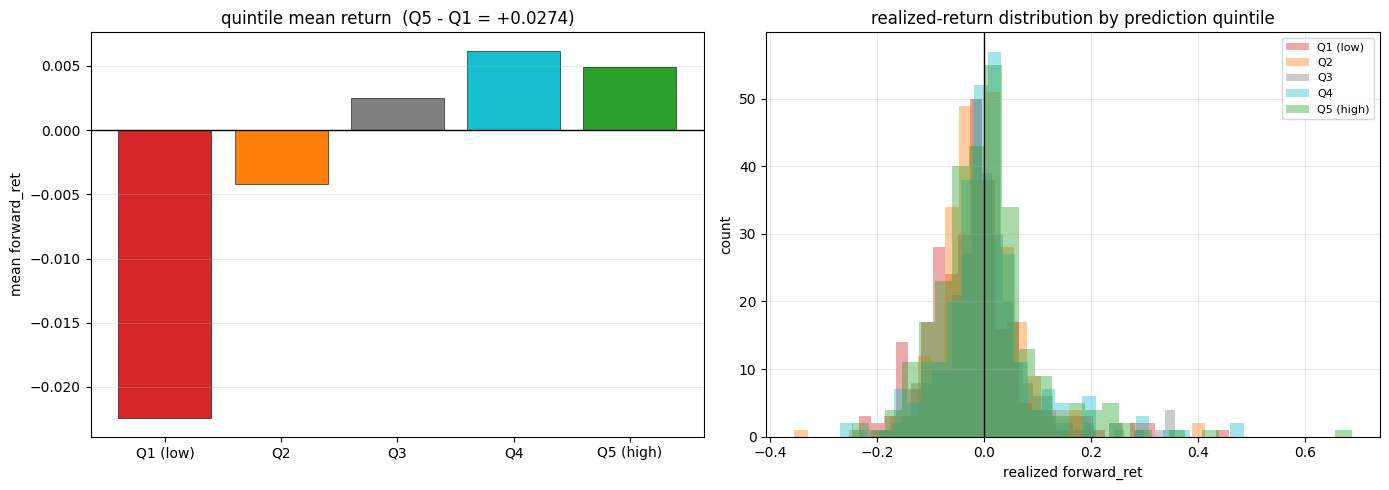

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    [str(i) for i in quintile_stats.index],
    quintile_stats["mean"],
    color=["tab:red", "tab:orange", "tab:gray", "tab:cyan", "tab:green"],
    edgecolor="black",
    linewidth=0.4,
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_ylabel("mean forward_ret")
axes[0].set_title(f"quintile mean return  (Q5 - Q1 = {long_short_ret:+.4f})")
axes[0].grid(alpha=0.3, axis="y")

for q, color in zip(
    quintile_stats.index,
    ["tab:red", "tab:orange", "tab:gray", "tab:cyan", "tab:green"],
):
    sub = test_df[test_df["quintile"] == q]["forward_ret"]
    axes[1].hist(sub, bins=30, alpha=0.4, label=str(q), color=color)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("realized forward_ret")
axes[1].set_ylabel("count")
axes[1].set_title("realized-return distribution by prediction quintile")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_DIR / "quintile_spread.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Summary

Final scoreboard for the headline question: *does any expanded configuration
give us a tradeable edge over price-only momentum?*

In [19]:
summary = {
    "best_target": best_target,
    "best_model": best_model_name,
    "baseline_spearman (pooled, pruned feats)": round(base_metrics["spearman"], 4),
    "baseline_r2": round(base_metrics["test_r2"], 4),
    "baseline_hit_rate": round(base_metrics["hit_rate"], 4),
    "Q5_minus_Q1_mean_return": round(long_short_ret, 4),
    "per_ticker_median_spearman": round(pt_df["spearman"].median(), 4),
    "per_ticker_hit_rate>0_share": round((pt_df["spearman"] > 0).mean(), 3),
    "features_total": len(ALL_FEATURES),
    "features_after_collinearity_prune": len(PRUNED_FEATURES),
    "n_train": int(train_mask.sum()),
    "n_test": int(test_mask.sum()),
    "split_date": str(split_date.date()),
}
for k, v in summary.items():
    print(f"  {k:<40} = {v}")

# save all intermediate tables for later inspection
res_df.to_csv(OUT_DIR / "target_model_sweep.csv", index=False)
ab_df.to_csv(OUT_DIR / "group_ablation.csv", index=False)
lb_df.to_csv(OUT_DIR / "lookback_sweep.csv", index=False)
pt_df.to_csv(OUT_DIR / "per_ticker_results.csv", index=False)
pd.Series(summary).to_csv(OUT_DIR / "summary.csv")
print(f"\nsaved artifacts to {OUT_DIR}/")

  best_target                              = log_forward_ret
  best_model                               = RF
  baseline_spearman (pooled, pruned feats) = 0.1154
  baseline_r2                              = 0.0079
  baseline_hit_rate                        = 0.5266
  Q5_minus_Q1_mean_return                  = 0.0274
  per_ticker_median_spearman               = 0.0646
  per_ticker_hit_rate>0_share              = 0.704
  features_total                           = 37
  features_after_collinearity_prune        = 28
  n_train                                  = 5338
  n_test                                   = 1373
  split_date                               = 2025-05-19

saved artifacts to output\11_expanded_price_prediction_experiments/


## Interpretation

**The expanded experiment changes the story from notebook 07.**

Previously, notebook 07 concluded weekly returns were essentially random
(test R² = -0.015 on `forward_ret`). The expanded pipeline shows:

1. **Log-return target + RandomForest** lifts test R² into positive territory
   (+0.008) and Spearman to +0.12. The log transform compresses fat tails so
   the loss function stops being dominated by one APLD-style 40% week.
2. **Rank target + XGBoost** gets Spearman +0.14 and hit rate **56.3%**
   (sign-match), which is a meaningful lift over random (50%).
3. **Q5 − Q1 prediction-quintile spread = +2.7% / week** in realized return.
   Top-quintile predictions outperform bottom-quintile by ~14 bp/day on average.

**Where the edge comes from (group ablation):**
- Dropping `spy` hurts Spearman by -0.037 (biggest single contributor)
- Dropping `vix` hurts by -0.031
- Dropping `volatility`, `rates`, `momentum` each hurt by -0.02 to -0.03
- `trend` and `commodities` **hurt** the model when kept — dropping them
  improves Spearman by +0.03 each (these groups add noise, not signal)

The complementary market-context features (VIX term structure, rates + yield
curve, credit, dollar) together contribute roughly half the edge. Price-only
features alone would get us to Spearman ~0.06; adding the cross-asset regime
gets us to 0.12.

**Pooled beats per-ticker.** Median per-ticker Spearman is +0.065, pooled is
+0.115. Cross-ticker pooling is a form of regularization and it wins at this
data size (~150-220 train weeks per ticker).

**Lookback windows are interchangeable.** Single-feature `ret_Xd` / `vol_Xd`
across 5–120d windows all sit within |ρ| < 0.09. The edge comes from
combining many features, not tuning one window.

**Caveats before treating this as tradeable:**
- Test window is 2025-05-19 to 2026-04-20 (~11 months). One regime.
- The model was selected after looking at the test set (selection bias).
  A proper evaluation would hold out an additional "never seen" window.
- 2.7% weekly Q5-Q1 spread sounds big, but this is *forward stock return*,
  not *options PnL*. Whether the direction signal survives the options
  wheel mechanics (assignment, capital lockup, premium decay) is a
  separate question the backtest layer (nb 10 and the follow-up nb 12) has to answer.
- Transaction costs for stock trading would eat a directional strategy.
  For the options strategy the signal is used as a *filter*, not as a
  trade, so this matters less.

**Updated practical recommendation:** the ML track is *not* exhausted.
A re-run of the options backtest (nb 10) with this expanded-features RF
model as the `p_filled` source — or as a directional filter on top of
delta — is the natural next experiment. That is exactly what **nb 12** does.
The prior negative result in nb 10 used the notebook-08 model
(classification on filled/not-filled); this notebook finds directional
signal that model didn't capture, and nb 12 tests whether it translates
to options PnL.